# Tipos de Variáveis — Fundos de Investimento (CVM)

**Atividade:** Entender e classificar tipos de variáveis  
**Dataset:** Informes Diários e Cadastro de Fundos de Investimento — CVM  
**Fonte:** [dados.cvm.gov.br](https://dados.cvm.gov.br)

---

## Contexto

A CVM (Comissão de Valores Mobiliários) disponibiliza publicamente dados de todos os fundos de investimento registrados no Brasil. São dois conjuntos principais:

- **Cadastro de Fundos (`cad_fi.csv`):** dados cadastrais — nome, tipo, gestor, administrador, situação.
- **Informes Diários (`inf_diario_fi_YYYYMM.csv`):** dados operacionais diários — valor da cota, patrimônio líquido, captação, resgates, número de cotistas.

Juntos, esses datasets cobrem todos os tipos principais de variáveis estudados em ciência de dados, dentro de um contexto direto de risco no mercado de capitais.

---

## Mapa de Tipos de Variáveis

```
Variáveis
├── Qualitativas (Categóricas)
│   ├── Nominal  → sem ordem (ex: tipo de fundo, gestor)
│   └── Ordinal  → com ordem (ex: classificação de risco, faixa de patrimônio)
│
└── Quantitativas (Numéricas)
    ├── Discreta → valores inteiros contáveis (ex: número de cotistas)
    └── Contínua → valores reais em intervalo (ex: valor da cota, PL)

Tipo especial:
└── Temporal  → datas e séries no tempo (ex: DT_COMPTC)
```

## 1. Bibliotecas

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import io
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 4)
sns.set_theme(style="whitegrid", palette="muted")

## 2. Download dos Dados

Baixamos diretamente da API aberta da CVM, sem necessidade de cadastro ou chave.

In [49]:
import zipfile

def baixar_cvm_csv(url: str, encoding: str = "latin1") -> pd.DataFrame:
    """Baixa um arquivo CSV (ou ZIP contendo CSV) da CVM e retorna como DataFrame."""
    print(f"Baixando: {url}")
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    response = requests.get(url, timeout=120, headers=headers)
    response.raise_for_status()

    if url.endswith(".zip"):
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            nome_csv = [f for f in z.namelist() if f.endswith(".csv")][0]
            with z.open(nome_csv) as f:
                return pd.read_csv(f, sep=";", encoding=encoding, low_memory=False)

    return pd.read_csv(io.BytesIO(response.content), sep=";", encoding=encoding, low_memory=False)


# Cadastro de Fundos — CSV direto (funciona sem ZIP)
URL_CADASTRO = "https://dados.cvm.gov.br/dados/FI/CAD/DADOS/cad_fi.csv"

# Informes Diários — usar formato ZIP (ajuste o mês: YYYYMM)
URL_INFORME = "https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_202602.zip"

cad = baixar_cvm_csv(URL_CADASTRO)
inf = baixar_cvm_csv(URL_INFORME)

print(f"\nCadastro:  {cad.shape[0]:,} fundos × {cad.shape[1]} colunas")
print(f"Informes:  {inf.shape[0]:,} registros × {inf.shape[1]} colunas")

Baixando: https://dados.cvm.gov.br/dados/FI/CAD/DADOS/cad_fi.csv
Baixando: https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_202602.zip

Cadastro:  46,812 fundos × 41 colunas
Informes:  455,468 registros × 10 colunas


## 3. Exploração Inicial

In [50]:
print("=== CADASTRO DE FUNDOS ===")
cad.head(3)

=== CADASTRO DE FUNDOS ===


,TP_FUNDO,CNPJ_FUNDO,DENOM_SOCIAL,DT_REG,DT_CONST,CD_CVM,DT_CANCEL,SIT,DT_INI_SIT,DT_INI_ATIV,...,CPF_CNPJ_GESTOR,GESTOR,CNPJ_AUDITOR,AUDITOR,CNPJ_CUSTODIANTE,CUSTODIANTE,CNPJ_CONTROLADOR,CONTROLADOR,INVEST_CEMPR_EXTER,CLASSE_ANBIMA
0,FACFIF,00.000.684/0001-21,DEUTSCHE BANK FDO APLIC QUOTAS FDO INV FINANCEIRO - MAX,2003-04-30,1994-12-20,19.0,2000-08-01,CANCELADA,2000-08-01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FACFIF,00.000.731/0001-37,ITAMARITI CASH FUNDO APLICACAO QUOTAS FDOS INVESTIMENTO,2003-04-30,1994-05-18,40681.0,1996-01-26,CANCELADA,1996-01-26,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FACFIF,00.000.732/0001-81,FUNDO APLIC. QUOTAS DE F.I. SANTANDER CURTO PRAZO,2003-04-30,1994-05-24,27.0,1999-09-03,CANCELADA,1999-09-03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
print("=== INFORMES DIÁRIOS ===")
inf.head(3)

=== INFORMES DIÁRIOS ===


,TP_FUNDO_CLASSE,CNPJ_FUNDO_CLASSE,ID_SUBCLASSE,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
0,CLASSES - FIF,00.017.024/0001-53,NaN,2026-02-02,1079754.37,42.000237,1205544.80,0.0,0.0,1
1,CLASSES - FIF,00.017.024/0001-53,NaN,2026-02-03,1080359.41,42.019089,1206085.93,0.0,0.0,1
2,CLASSES - FIF,00.017.024/0001-53,NaN,2026-02-04,1080998.82,42.038218,1206635.00,0.0,0.0,1


In [52]:
# Tipos inferidos pelo pandas (ainda sem classificação semântica)
print("--- Cadastro: dtypes ---")
print(cad.dtypes)
print("\n--- Informes: dtypes ---")
print(inf.dtypes)

--- Cadastro: dtypes ---
TP_FUNDO               object
CNPJ_FUNDO             object
DENOM_SOCIAL           object
DT_REG                 object
DT_CONST               object
CD_CVM                float64
DT_CANCEL              object
SIT                    object
DT_INI_SIT             object
DT_INI_ATIV            object
DT_INI_EXERC           object
DT_FIM_EXERC           object
CLASSE                 object
DT_INI_CLASSE          object
RENTAB_FUNDO           object
CONDOM                 object
FUNDO_COTAS            object
FUNDO_EXCLUSIVO        object
TRIB_LPRAZO            object
PUBLICO_ALVO           object
ENTID_INVEST           object
TAXA_PERFM            float64
INF_TAXA_PERFM         object
TAXA_ADM              float64
INF_TAXA_ADM           object
VL_PATRIM_LIQ         float64
DT_PATRIM_LIQ          object
DIRETOR                object
CNPJ_ADMIN             object
ADMIN                  object
PF_PJ_GESTOR           object
CPF_CNPJ_GESTOR        object
GESTOR         

## 4. Conversões de Tipos

O pandas infere `object` para strings e `float64`/`int64` para números. Datas precisam ser convertidas explicitamente.

In [53]:
# Converter colunas de data
inf["DT_COMPTC"] = pd.to_datetime(inf["DT_COMPTC"])
cad["DT_REG"] = pd.to_datetime(cad["DT_REG"], errors="coerce")
cad["DT_CANCEL"] = pd.to_datetime(cad["DT_CANCEL"], errors="coerce")
cad["DT_INI_ATIV"] = pd.to_datetime(cad["DT_INI_ATIV"], errors="coerce")

# Número de cotistas deve ser inteiro
inf["NR_COTST"] = inf["NR_COTST"].fillna(0).astype(int)

# Renomear colunas do informe para nomes mais legíveis (formato CVM mudou em 2024)
inf = inf.rename(columns={
    "CNPJ_FUNDO_CLASSE": "CNPJ_FUNDO",
    "CAPTC_DIA":         "VL_CAPTC_DIA",
    "RESG_DIA":          "VL_RESG_DIA",
})

print("Colunas do informe após renomeação:")
print(inf.columns.tolist())

Colunas do informe após renomeação:
['TP_FUNDO_CLASSE', 'CNPJ_FUNDO', 'ID_SUBCLASSE', 'DT_COMPTC', 'VL_TOTAL', 'VL_QUOTA', 'VL_PATRIM_LIQ', 'VL_CAPTC_DIA', 'VL_RESG_DIA', 'NR_COTST']


## 5. Classificação das Variáveis

---

### 5.1 Variável Qualitativa Nominal

> **Definição:** categorias sem relação de ordem entre si.  
> Pergunta-chave: *"Faz sentido dizer que A é maior ou melhor que B?"* → Se **não**, é nominal.

**Exemplos no dataset:**
- `CNPJ_FUNDO` — identificador único do fundo (nominal por excelência)
- `DENOM_SOCIAL` — razão social do fundo
- `NM_GESTOR` — nome do gestor
- `TP_FUNDO` — tipo de fundo (FIA, FIM, FIRF, FIC...)

In [54]:
print("Tipos de fundo (TP_FUNDO) — variável qualitativa nominal:")
print(cad["TP_FUNDO"].value_counts().head(10))
print(f"\nTotal de categorias únicas: {cad['TP_FUNDO'].nunique()}")

Tipos de fundo (TP_FUNDO) — variável qualitativa nominal:
TP_FUNDO
FI         29540
FIF         5228
FACFIF      5211
FIDC        1891
FIP         1634
FITVM        842
FMIA-CL      775
FII          518
FMIA         229
FIEX         206
Name: count, dtype: int64

Total de categorias únicas: 27


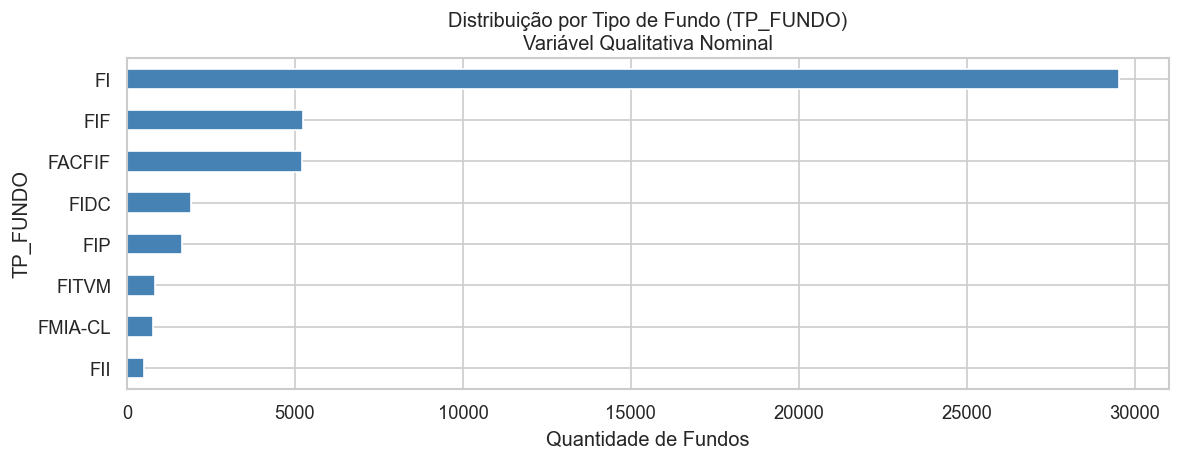

In [55]:
fig, ax = plt.subplots(figsize=(10, 4))
cad["TP_FUNDO"].value_counts().head(8).plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Distribuição por Tipo de Fundo (TP_FUNDO)\nVariável Qualitativa Nominal", fontsize=12)
ax.set_xlabel("Quantidade de Fundos")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> **Nota sobre risco:** o tipo do fundo (`TP_FUNDO`) determina a política de investimento e, portanto, o perfil de risco. Um FIA (Fundo de Ações) tem risco de mercado muito diferente de um FIRF (Fundo de Renda Fixa). Essa variável nominal é frequentemente usada como critério de segmentação em análises de risco.

---

### 5.2 Variável Qualitativa Ordinal

> **Definição:** categorias com ordem natural definida, mas sem diferença quantitativa precisa entre elas.  
> Pergunta-chave: *"Posso dizer que A é maior/melhor que B, mas não quanto?"* → Se **sim**, é ordinal.

**Exemplos no dataset:**
- `SIT` — situação do fundo: `Em funcionamento normal` > `Em liquidação` > `Cancelado`
- Faixa de patrimônio líquido (variável derivada que criaremos abaixo)

In [56]:
print("Situação dos fundos (SIT) — variável qualitativa ordinal:")
print(cad["SIT"].value_counts())

Situação dos fundos (SIT) — variável qualitativa ordinal:
SIT
CANCELADA                  46561
LIQUIDAÇÃO                   121
FASE PRÉ-OPERACIONAL          87
EM FUNCIONAMENTO NORMAL       22
INCORPORAÇÃO                  10
EM ANÁLISE                     6
EM SITUAÇÃO ESPECIAL           5
Name: count, dtype: int64


In [57]:
# Criando variável ordinal de faixa de PL a partir dos informes
pl_por_fundo = inf.groupby("CNPJ_FUNDO")["VL_PATRIM_LIQ"].mean()

bins = [0, 1e6, 10e6, 100e6, 1e9, float("inf")]
labels = ["< R$1M", "R$1M–10M", "R$10M–100M", "R$100M–1B", "> R$1B"]

faixa_pl = pd.cut(pl_por_fundo, bins=bins, labels=labels, right=True)

# Ordem importa — definimos explicitamente
faixa_pl = pd.Categorical(faixa_pl, categories=labels, ordered=True)

print("Faixa de PL médio (variável ordinal derivada):")
print(pd.Series(faixa_pl).value_counts().sort_index())

Faixa de PL médio (variável ordinal derivada):
< R$1M          205
R$1M–10M       3542
R$10M–100M    12665
R$100M–1B      7052
> R$1B         1810
Name: count, dtype: int64


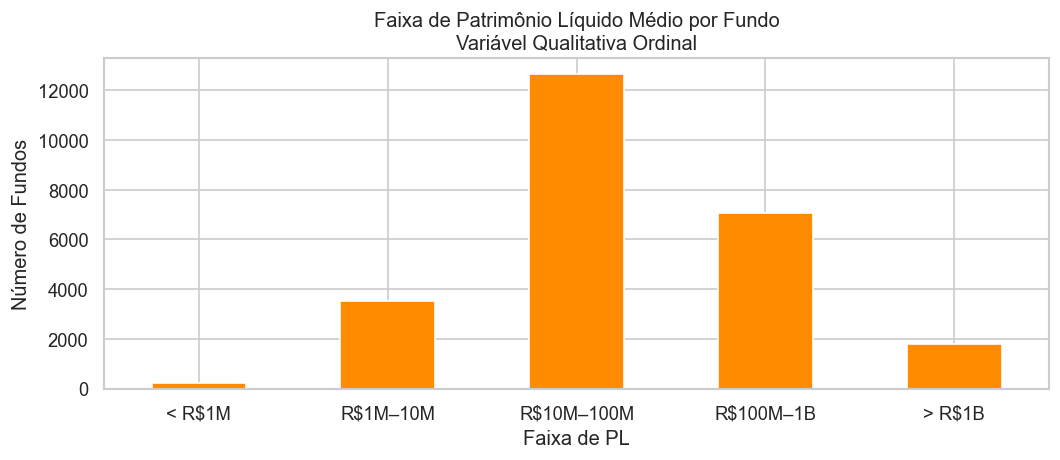

In [58]:
fig, ax = plt.subplots(figsize=(9, 4))
pd.Series(faixa_pl).value_counts().sort_index().plot(kind="bar", ax=ax, color="darkorange", edgecolor="white")
ax.set_title("Faixa de Patrimônio Líquido Médio por Fundo\nVariável Qualitativa Ordinal", fontsize=12)
ax.set_xlabel("Faixa de PL")
ax.set_ylabel("Número de Fundos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> **Nota sobre risco:** a faixa de PL é uma proxy de tamanho e liquidez. Fundos maiores geralmente têm menor risco de liquidez. A ordem importa: um fundo `> R$1B` tem perfil de liquidez sistematicamente diferente de um `< R$1M`.

---

### 5.3 Variável Quantitativa Discreta

> **Definição:** valores numéricos inteiros e contáveis. Não faz sentido ter 2,7 cotistas.  
> Pergunta-chave: *"Os valores são contáveis e inteiros?"* → Se **sim**, é discreta.

**Exemplos no dataset:**
- `NR_COTST` — número de cotistas do fundo no dia

In [59]:
print("Estatísticas descritivas — NR_COTST (variável discreta):")
print(inf["NR_COTST"].describe().apply(lambda x: f"{x:,.0f}"))

Estatísticas descritivas — NR_COTST (variável discreta):
count    455,468
mean       1,071
std       15,081
min            0
25%            1
50%            2
75%           15
max      816,896
Name: NR_COTST, dtype: object


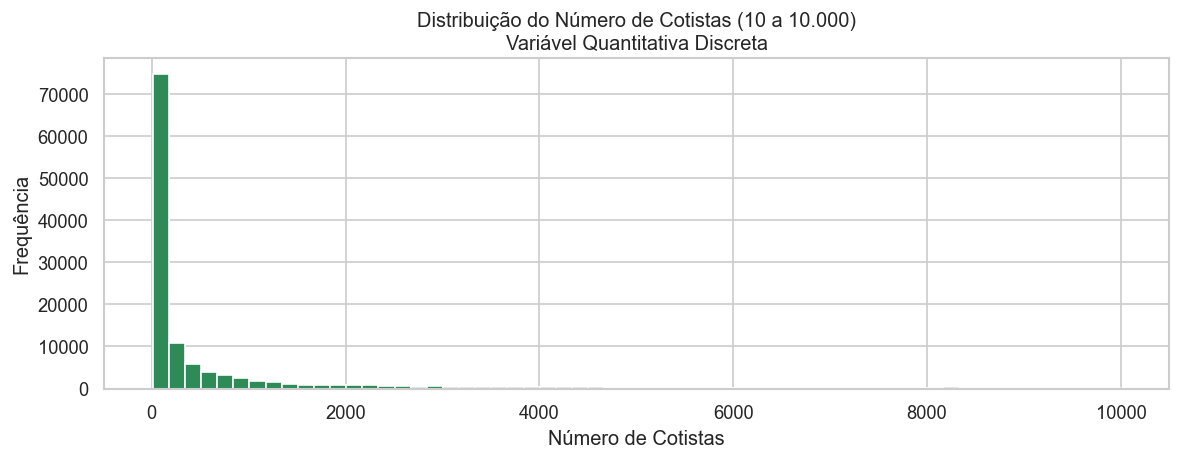

In [60]:
# Focamos em fundos com cotistas entre 10 e 10.000 para melhor visualização
amostra_cotistas = inf.loc[
    inf["NR_COTST"].between(10, 10_000), "NR_COTST"
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(amostra_cotistas, bins=60, color="seagreen", edgecolor="white")
ax.set_title("Distribuição do Número de Cotistas (10 a 10.000)\nVariável Quantitativa Discreta", fontsize=12)
ax.set_xlabel("Número de Cotistas")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

> **Nota sobre risco:** o número de cotistas influencia o risco de liquidez do fundo. Um fundo com poucos cotistas concentrados pode sofrer resgates massivos em momentos de estresse, forçando a venda de ativos a preços desfavoráveis — o chamado **risco de resgate concentrado**.

---

### 5.4 Variável Quantitativa Contínua

> **Definição:** valores numéricos que podem assumir qualquer valor dentro de um intervalo — incluindo decimais.  
> Pergunta-chave: *"O valor pode ser fracionado indefinidamente?"* → Se **sim**, é contínua.

**Exemplos no dataset:**
- `VL_QUOTA` — valor da cota (R$)
- `VL_PATRIM_LIQ` — patrimônio líquido (R$)
- `VL_CAPTC_DIA` — captação do dia (R$)
- `VL_RESG_DIA` — resgates do dia (R$)

In [61]:
print("Estatísticas descritivas — variáveis contínuas:")
cols_continuas = ["VL_QUOTA", "VL_PATRIM_LIQ", "VL_CAPTC_DIA", "VL_RESG_DIA"]
inf[cols_continuas].describe().map(lambda x: f"{x:,.2f}")

Estatísticas descritivas — variáveis contínuas:


,VL_QUOTA,VL_PATRIM_LIQ,VL_CAPTC_DIA,VL_RESG_DIA
count,"455,468.00","455,468.00","455,468.00","455,468.00"
mean,"12,737.54","530,717,083.40","3,404,543.40","3,266,367.84"
std,"681,013.83","3,933,532,711.93","75,098,203.73","69,037,760.11"
min,"-16,068.95","-1,112,418,167.10",0.00,0.00
25%,1.36,"17,750,702.02",0.00,0.00
50%,2.24,"49,417,333.23",0.00,0.00
75%,23.33,"176,368,065.20",0.00,0.00
max,"93,868,708.07","251,611,298,615.79","16,829,155,729.61","10,144,467,426.68"


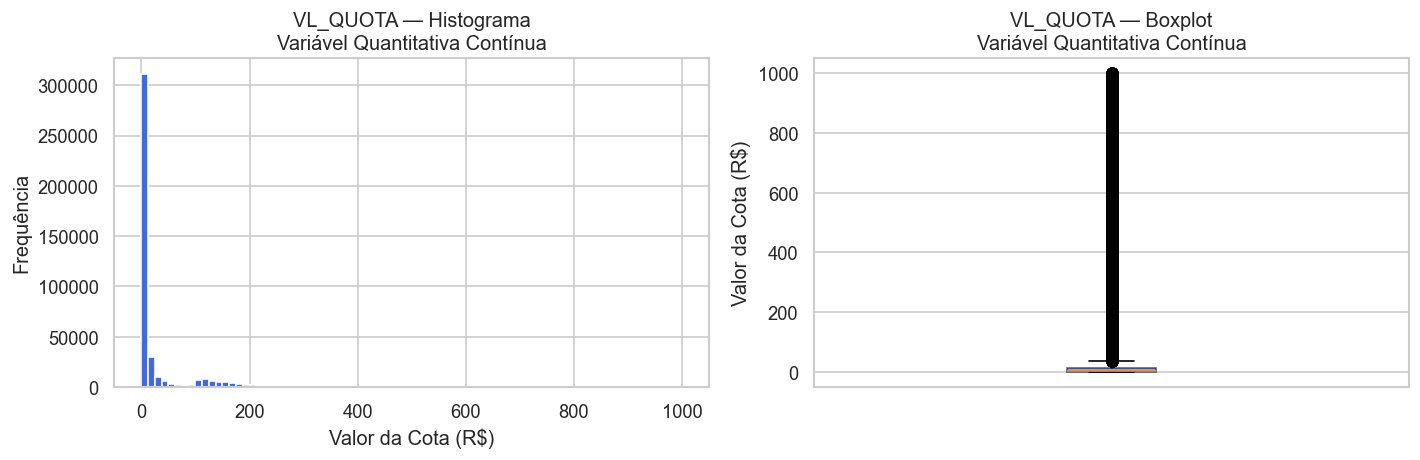

In [62]:
# Distribuição do Valor da Cota (excluindo outliers extremos)
cotas = inf.loc[inf["VL_QUOTA"].between(0.01, 1000), "VL_QUOTA"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(cotas, bins=80, color="royalblue", edgecolor="white")
axes[0].set_title("VL_QUOTA — Histograma\nVariável Quantitativa Contínua")
axes[0].set_xlabel("Valor da Cota (R$)")
axes[0].set_ylabel("Frequência")

# Boxplot
axes[1].boxplot(cotas, vert=True, patch_artist=True,
                boxprops=dict(facecolor="royalblue", alpha=0.6))
axes[1].set_title("VL_QUOTA — Boxplot\nVariável Quantitativa Contínua")
axes[1].set_ylabel("Valor da Cota (R$)")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

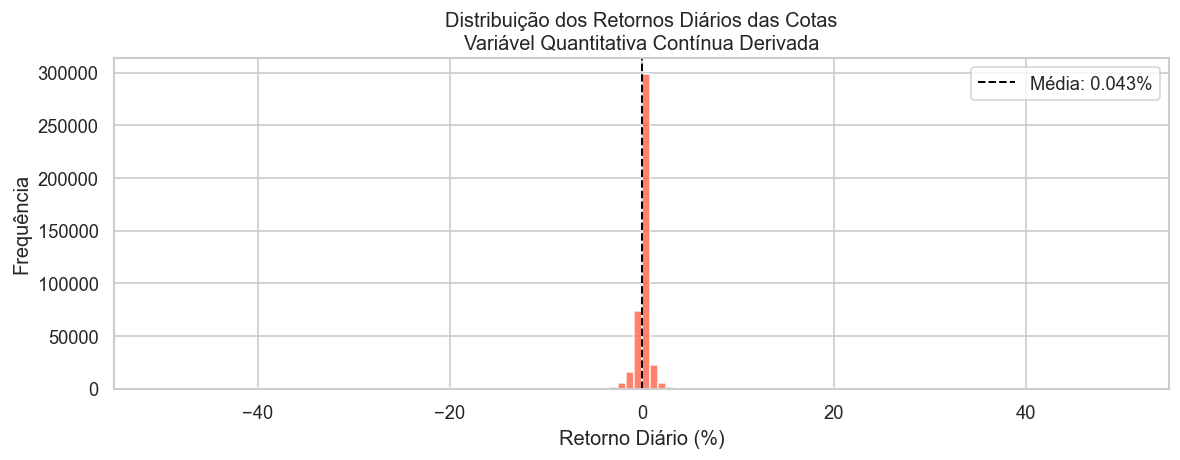

Média dos retornos diários: 0.0429%
Desvio padrão:             1.6548%
Curtose:                   346.35  (> 3 indica caudas pesadas — relevante para VaR)


In [63]:
# Retorno diário das cotas (variável contínua derivada — fundamental em risco de mercado)
# Calculamos o retorno percentual diário por fundo

# Filtramos fundos com dados suficientes no período
inf_sorted = inf.sort_values(["CNPJ_FUNDO", "DT_COMPTC"])
inf_sorted["RETORNO_DIARIO"] = inf_sorted.groupby("CNPJ_FUNDO")["VL_QUOTA"].pct_change()

retornos = inf_sorted["RETORNO_DIARIO"].dropna()
retornos = retornos[retornos.between(-0.5, 0.5)]  # remove outliers extremos

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(retornos * 100, bins=120, color="tomato", edgecolor="white", alpha=0.8)
ax.set_title("Distribuição dos Retornos Diários das Cotas\nVariável Quantitativa Contínua Derivada", fontsize=12)
ax.set_xlabel("Retorno Diário (%)")
ax.set_ylabel("Frequência")

# Média e desvio padrão
media = retornos.mean() * 100
desvio = retornos.std() * 100
ax.axvline(media, color="black", linestyle="--", linewidth=1.2, label=f"Média: {media:.3f}%")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Média dos retornos diários: {media:.4f}%")
print(f"Desvio padrão:             {desvio:.4f}%")
print(f"Curtose:                   {retornos.kurtosis():.2f}  (> 3 indica caudas pesadas — relevante para VaR)")

> **Nota sobre risco:** o retorno diário é a variável central em modelos de **Value at Risk (VaR)**. A distribuição dos retornos raramente é normal — observe a curtose elevada, que indica caudas mais pesadas que a distribuição gaussiana. Isso tem impacto direto na estimação do VaR paramétrico.

---

### 5.5 Variável Temporal

> **Definição:** registros de data e/ou hora que carregam ordenação natural e permitem análise de séries temporais.  
> Observação: tecnicamente são um tipo especial de variável contínua ordinal, mas merecem tratamento próprio em análise de dados.

**Exemplos no dataset:**
- `DT_COMPTC` — data de competência do informe
- `DT_REG` — data de registro do fundo na CVM
- `DT_INI_ATIV` — data de início de atividade
- `DT_CANCEL` — data de cancelamento (quando aplicável)

In [64]:
print("Intervalo de datas no informe:")
print(f"  Início: {inf['DT_COMPTC'].min().date()}")
print(f"  Fim:    {inf['DT_COMPTC'].max().date()}")
print(f"  Dias úteis: {inf['DT_COMPTC'].nunique()}")

Intervalo de datas no informe:
  Início: 2026-02-02
  Fim:    2026-02-27
  Dias úteis: 19


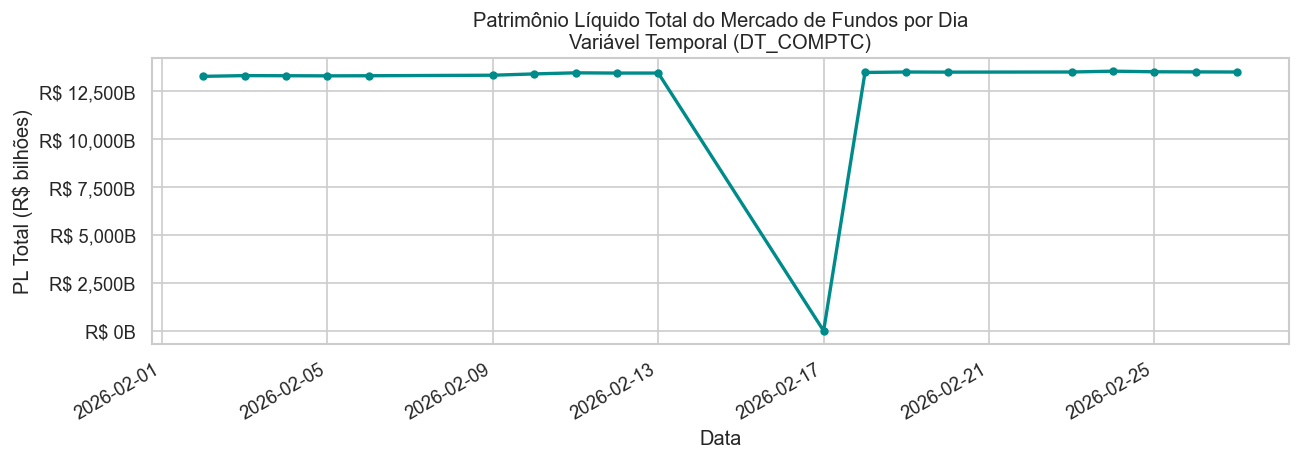

In [65]:
# Série temporal: PL total do mercado de fundos dia a dia
pl_diario = inf.groupby("DT_COMPTC")["VL_PATRIM_LIQ"].sum() / 1e9  # em bilhões

fig, ax = plt.subplots(figsize=(11, 4))
pl_diario.plot(ax=ax, color="darkcyan", linewidth=2, marker="o", markersize=4)
ax.set_title("Patrimônio Líquido Total do Mercado de Fundos por Dia\nVariável Temporal (DT_COMPTC)", fontsize=12)
ax.set_xlabel("Data")
ax.set_ylabel("PL Total (R$ bilhões)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"R$ {x:,.0f}B"))
plt.tight_layout()
plt.show()

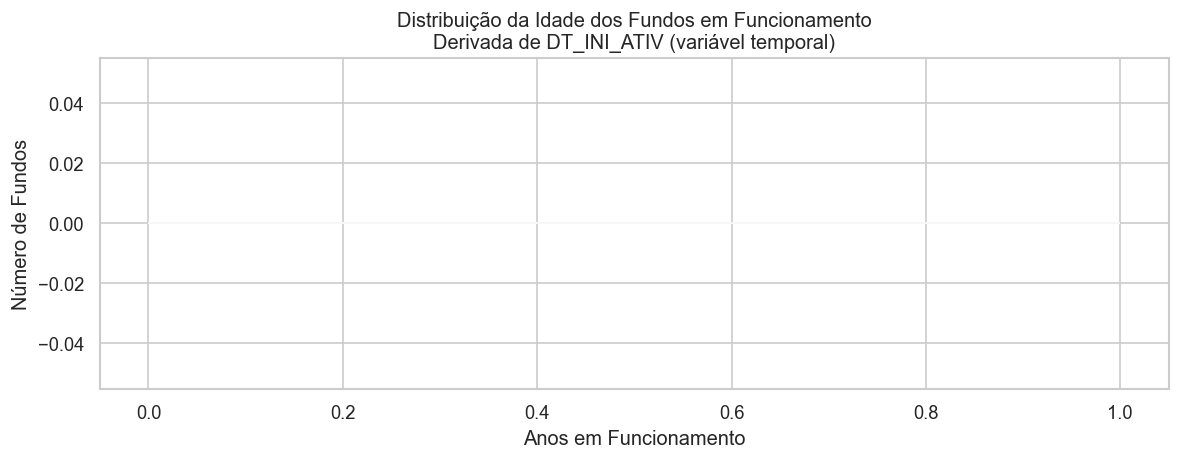

In [66]:
# Antiguidade dos fundos ativos (variável derivada de datas)
fundos_ativos = cad[cad["SIT"] == "Em funcionamento normal"].copy()
hoje = pd.Timestamp.today()
fundos_ativos["ANOS_ATIVO"] = (hoje - fundos_ativos["DT_INI_ATIV"]).dt.days / 365.25
fundos_ativos = fundos_ativos[fundos_ativos["ANOS_ATIVO"].between(0, 40)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(fundos_ativos["ANOS_ATIVO"], bins=40, color="mediumpurple", edgecolor="white")
ax.set_title("Distribuição da Idade dos Fundos em Funcionamento\nDerivada de DT_INI_ATIV (variável temporal)", fontsize=12)
ax.set_xlabel("Anos em Funcionamento")
ax.set_ylabel("Número de Fundos")
plt.tight_layout()
plt.show()

## 6. Tabela-Resumo das Variáveis Classificadas

| Variável | Dataset | Tipo Estatístico | Tipo Pandas | Relevância para Risco |
|---|---|---|---|---|
| `CNPJ_FUNDO` | Ambos | Qualit. Nominal | object | Identificação do veículo |
| `TP_FUNDO` | Cadastro | Qualit. Nominal | object | Política de investimento e perfil de risco |
| `NM_GESTOR` | Cadastro | Qualit. Nominal | object | Risco operacional / concentração de gestor |
| `SIT` | Cadastro | Qualit. Ordinal | object | Situação regulatória do fundo |
| `Faixa_PL` | Derivada | Qualit. Ordinal | Categorical | Proxy de liquidez e porte |
| `NR_COTST` | Informe | Quant. Discreta | int64 | Risco de resgate concentrado |
| `VL_QUOTA` | Informe | Quant. Contínua | float64 | Valor de referência para precificação |
| `VL_PATRIM_LIQ` | Informe | Quant. Contínua | float64 | Tamanho e liquidez do fundo |
| `VL_CAPTC_DIA` | Informe | Quant. Contínua | float64 | Fluxo de entrada (pressão de alocação) |
| `VL_RESG_DIA` | Informe | Quant. Contínua | float64 | Fluxo de saída (pressão de liquidação) |
| `RETORNO_DIARIO` | Derivada | Quant. Contínua | float64 | Input direto para modelos de VaR |
| `DT_COMPTC` | Informe | Temporal | datetime64 | Eixo da série temporal de cotas |
| `DT_INI_ATIV` | Cadastro | Temporal | datetime64 | Track record / maturidade do fundo |

## 7. Dicionário Automático de Variáveis (Entregável Extra)

Função que percorre qualquer DataFrame e gera automaticamente um dicionário de dados com:
- tipo semântico classificado
- estatísticas descritivas adequadas ao tipo
- contagem de nulos
- exemplos de valores reais

O mapeamento de tipo semântico é declarado explicitamente — isso força o analista a pensar e registrar sua classificação, que fica documentada junto ao código.

In [67]:
def gerar_dicionario(df: pd.DataFrame, tipo_semantico: dict, descricoes: dict = None) -> pd.DataFrame:
    """
    Gera um dicionário automático de variáveis para um DataFrame.

    Parâmetros
    ----------
    df : pd.DataFrame
        Dataset a ser documentado.
    tipo_semantico : dict
        Mapeamento coluna → tipo (ex: {"CNPJ_FUNDO": "Qualit. Nominal"}).
    descricoes : dict, opcional
        Mapeamento coluna → descrição textual da variável.

    Retorna
    -------
    pd.DataFrame com uma linha por variável e colunas de metadados.
    """
    if descricoes is None:
        descricoes = {}

    registros = []

    for col in df.columns:
        serie = df[col]
        dtype = str(serie.dtype)
        n_total = len(serie)
        n_nulos = serie.isna().sum()
        pct_nulos = n_nulos / n_total * 100
        n_unicos = serie.nunique(dropna=True)

        # Exemplos: 3 primeiros valores não nulos
        exemplos = serie.dropna().unique()[:3].tolist()
        exemplos_str = " | ".join(str(e) for e in exemplos)

        # Estatísticas conforme tipo
        tipo = tipo_semantico.get(col, "Não classificado")
        stats = {}

        if "Contínua" in tipo or "Discreta" in tipo:
            num = pd.to_numeric(serie, errors="coerce")
            stats["min"] = f"{num.min():,.4f}"
            stats["max"] = f"{num.max():,.4f}"
            stats["média"] = f"{num.mean():,.4f}"
            stats["desvio_pad"] = f"{num.std():,.4f}"
            stats["mediana"] = f"{num.median():,.4f}"
        elif "Temporal" in tipo:
            dt = pd.to_datetime(serie, errors="coerce")
            stats["min"] = str(dt.min().date()) if not pd.isna(dt.min()) else "—"
            stats["max"] = str(dt.max().date()) if not pd.isna(dt.max()) else "—"
            stats["média"] = "—"
            stats["desvio_pad"] = "—"
            stats["mediana"] = "—"
        else:
            moda = serie.mode()
            stats["min"] = "—"
            stats["max"] = "—"
            stats["média"] = "—"
            stats["desvio_pad"] = "—"
            stats["mediana"] = f"{moda.iloc[0]}" if not moda.empty else "—"

        registros.append({
            "variável": col,
            "tipo_pandas": dtype,
            "tipo_semântico": tipo,
            "descrição": descricoes.get(col, ""),
            "nulos": n_nulos,
            "nulos_%": f"{pct_nulos:.1f}%",
            "únicos": n_unicos,
            "exemplos": exemplos_str,
            "min": stats["min"],
            "max": stats["max"],
            "média": stats["média"],
            "desvio_pad": stats["desvio_pad"],
            "mediana": stats["mediana"],
        })

    return pd.DataFrame(registros).set_index("variável")

In [68]:
# --- Mapeamento semântico: Cadastro de Fundos ---

tipos_cad = {
    "TP_FUNDO":       "Qualit. Nominal",
    "CNPJ_FUNDO":     "Qualit. Nominal",
    "DENOM_SOCIAL":   "Qualit. Nominal",
    "SIT":            "Qualit. Ordinal",
    "CLASSE":         "Qualit. Nominal",
    "SUBCLASSE":      "Qualit. Nominal",
    "NM_GESTOR":      "Qualit. Nominal",
    "NM_ADMIN":       "Qualit. Nominal",
    "NM_CUSTODIANTE": "Qualit. Nominal",
    "NM_AUDITOR":     "Qualit. Nominal",
    "DT_REG":         "Temporal",
    "DT_CANCEL":      "Temporal",
    "DT_INI_ATIV":    "Temporal",
    "DT_INI_SIT":     "Temporal",
    "PUBLICO_ALVO":   "Qualit. Nominal",
    "FUNDO_COTAS":    "Qualit. Nominal",
    "FUNDO_EXCLUSIVO":"Qualit. Nominal",
    "TRIB_LPRAZO":    "Qualit. Nominal",
    "INVEST_QUALIF":  "Qualit. Nominal",
    "ENTID_INVEST":   "Qualit. Nominal",
    "TAXA_PERFM":     "Quant. Contínua",
    "INF_TAXA_PERFM": "Qualit. Nominal",
    "TAXA_ADM":       "Quant. Contínua",
    "INF_TAXA_ADM":   "Qualit. Nominal",
    "VL_PATRIM_LIQ":  "Quant. Contínua",
    "DT_PATRIM_LIQ":  "Temporal",
    "DIRETOR":        "Qualit. Nominal",
    "CPF_CNPJ_GESTOR":"Qualit. Nominal",
    "PF_PJ_GESTOR":   "Qualit. Nominal",
    "CNPJ_ADMIN":     "Qualit. Nominal",
    "CNPJ_CUSTODIANTE":"Qualit. Nominal",
    "CNPJ_AUDITOR":   "Qualit. Nominal",
    "TP_PRAZO":       "Qualit. Ordinal",
    "DT_FIM_EXERC":   "Temporal",
}

descricoes_cad = {
    "TP_FUNDO":        "Tipo de fundo (FIA, FIM, FIRF, FIC...)",
    "CNPJ_FUNDO":      "CNPJ do fundo — identificador único",
    "DENOM_SOCIAL":    "Razão social do fundo",
    "SIT":             "Situação cadastral: Em funcionamento normal / Em liquidação / Cancelado",
    "CLASSE":          "Classe CVM do fundo",
    "NM_GESTOR":       "Nome do gestor responsável pela carteira",
    "NM_ADMIN":        "Nome do administrador fiduciário",
    "DT_REG":          "Data de registro do fundo na CVM",
    "DT_INI_ATIV":     "Data de início efetivo das atividades",
    "DT_CANCEL":       "Data de cancelamento (quando aplicável)",
    "PUBLICO_ALVO":    "Público-alvo: Geral / Qualificado / Profissional",
    "TAXA_ADM":        "Taxa de administração anual (%)",
    "TAXA_PERFM":      "Taxa de performance anual (%)",
    "VL_PATRIM_LIQ":   "Patrimônio líquido informado no cadastro (R$)",
    "INVEST_QUALIF":   "Indica se o fundo é exclusivo para investidores qualificados",
}

dic_cad = gerar_dicionario(cad, tipos_cad, descricoes_cad)

pd.set_option("display.max_colwidth", 60)
print(f"Dicionário do Cadastro de Fundos — {len(dic_cad)} variáveis\n")
dic_cad

Dicionário do Cadastro de Fundos — 41 variáveis



,tipo_pandas,tipo_semântico,descrição,nulos,nulos_%,únicos,exemplos,min,max,média,desvio_pad,mediana
variável,,,,,,,,,,,,
TP_FUNDO,object,Qualit. Nominal,"Tipo de fundo (FIA, FIM, FIRF, FIC...)",0,0.0%,27,FACFIF | FAPI | FCCE,—,—,—,—,FI
CNPJ_FUNDO,object,Qualit. Nominal,CNPJ do fundo — identificador único,0,0.0%,41109,00.000.684/0001-21 | 00.000.731/0001-37 | 00.000.732/000...,—,—,—,—,00.207.967/0001-49
DENOM_SOCIAL,object,Qualit. Nominal,Razão social do fundo,0,0.0%,41066,DEUTSCHE BANK FDO APLIC QUOTAS FDO INV FINANCEIRO - MAX ...,—,—,—,—,ABN AMRO FUNDO DE INVESTIMENTO EM QUOTAS DE FUNDOS DE IN...
DT_REG,datetime64[ns],Temporal,Data de registro do fundo na CVM,0,0.0%,6219,2003-04-30 00:00:00 | 1994-05-27 00:00:00 | 1995-10-02 0...,1957-01-18,2024-09-24,—,—,—
DT_CONST,object,Não classificado,,1834,3.9%,7142,1994-12-20 | 1994-05-18 | 1994-05-24,—,—,—,—,1995-10-02
CD_CVM,float64,Não classificado,,6,0.0%,34206,19.0 | 40681.0 | 27.0,—,—,—,—,120224.0
DT_CANCEL,datetime64[ns],Temporal,Data de cancelamento (quando aplicável),250,0.5%,7154,2000-08-01 00:00:00 | 1996-01-26 00:00:00 | 1999-09-03 0...,1986-05-25,2026-03-25,—,—,—
SIT,object,Qualit. Ordinal,Situação cadastral: Em funcionamento normal / Em liquida...,0,0.0%,7,CANCELADA | EM FUNCIONAMENTO NORMAL | LIQUIDAÇÃO,—,—,—,—,CANCELADA
DT_INI_SIT,object,Temporal,,0,0.0%,7159,2000-08-01 | 1996-01-26 | 1999-09-03,1986-05-25,2026-03-25,—,—,—


In [69]:
# --- Mapeamento semântico: Informes Diários ---

tipos_inf = {
    "CNPJ_FUNDO":    "Qualit. Nominal",
    "DT_COMPTC":     "Temporal",
    "VL_TOTAL":      "Quant. Contínua",
    "VL_QUOTA":      "Quant. Contínua",
    "VL_PATRIM_LIQ": "Quant. Contínua",
    "CAPTC_DIA":     "Quant. Contínua",
    "VL_CAPTC_DIA":  "Quant. Contínua",
    "VL_RESG_DIA":   "Quant. Contínua",
    "NR_COTST":      "Quant. Discreta",
}

descricoes_inf = {
    "CNPJ_FUNDO":    "CNPJ do fundo — chave de ligação com o cadastro",
    "DT_COMPTC":     "Data de competência do informe diário",
    "VL_TOTAL":      "Valor total da carteira (R$)",
    "VL_QUOTA":      "Valor da cota no fechamento do dia (R$)",
    "VL_PATRIM_LIQ": "Patrimônio líquido do fundo no dia (R$)",
    "VL_CAPTC_DIA":  "Volume financeiro captado no dia (R$)",
    "VL_RESG_DIA":   "Volume financeiro resgatado no dia (R$)",
    "NR_COTST":      "Número de cotistas ao fim do dia",
}

dic_inf = gerar_dicionario(inf, tipos_inf, descricoes_inf)

print(f"Dicionário dos Informes Diários — {len(dic_inf)} variáveis\n")
dic_inf

Dicionário dos Informes Diários — 10 variáveis



,tipo_pandas,tipo_semântico,descrição,nulos,nulos_%,únicos,exemplos,min,max,média,desvio_pad,mediana
variável,,,,,,,,,,,,
TP_FUNDO_CLASSE,object,Não classificado,,0,0.0%,3,CLASSES - FIF | CLASSE FIF/FAPI | FI,—,—,—,—,CLASSES - FIF
CNPJ_FUNDO,object,Qualit. Nominal,CNPJ do fundo — chave de ligação com o cadastro,0,0.0%,25375,00.017.024/0001-53 | 00.068.305/0001-35 | 00.071.477/000...,—,—,—,—,29.726.133/0001-21
ID_SUBCLASSE,object,Não classificado,,445212,97.7%,601,RBMFN1747320951 | MZMRC1747322915 | GPZ7A1744144200,—,—,—,—,0AYDG1734640049
DT_COMPTC,datetime64[ns],Temporal,Data de competência do informe diário,0,0.0%,19,2026-02-02 00:00:00 | 2026-02-03 00:00:00 | 2026-02-04 0...,2026-02-02,2026-02-27,—,—,—
VL_TOTAL,float64,Quant. Contínua,Valor total da carteira (R$),0,0.0%,452096,1079754.37 | 1080359.41 | 1080998.82,"-944,412,625.6400","251,611,548,476.7300","533,240,830.3333","3,943,395,529.6920","49,331,197.6350"
VL_QUOTA,float64,Quant. Contínua,Valor da cota no fechamento do dia (R$),0,0.0%,450849,42.0002367 | 42.0190892 | 42.0382184,"-16,068.9504","93,868,708.0715","12,737.5370","681,013.8286",2.2400
VL_PATRIM_LIQ,float64,Quant. Contínua,Patrimônio líquido do fundo no dia (R$),0,0.0%,452328,1205544.8 | 1206085.93 | 1206635.0,"-1,112,418,167.1000","251,611,298,615.7900","530,717,083.3968","3,933,532,711.9343","49,417,333.2250"
VL_CAPTC_DIA,float64,Quant. Contínua,Volume financeiro captado no dia (R$),0,0.0%,74159,0.0 | 118447.81 | 6948.33,0.0000,"16,829,155,729.6100","3,404,543.3979","75,098,203.7323",0.0000
VL_RESG_DIA,float64,Quant. Contínua,Volume financeiro resgatado no dia (R$),0,0.0%,88613,0.0 | 46059.03 | 226.47,0.0000,"10,144,467,426.6800","3,266,367.8353","69,037,760.1128",0.0000


In [70]:
# --- Exportar dicionários para CSV ---
import os

os.makedirs("../../data/processed", exist_ok=True)

dic_cad.to_csv("../../data/processed/dicionario_cadastro_fundos.csv", encoding="utf-8-sig")
dic_inf.to_csv("../../data/processed/dicionario_informes_diarios.csv", encoding="utf-8-sig")

print("Dicionários exportados para data/processed/")
print("  → dicionario_cadastro_fundos.csv")
print("  → dicionario_informes_diarios.csv")

Dicionários exportados para data/processed/
  → dicionario_cadastro_fundos.csv
  → dicionario_informes_diarios.csv


## 8. Dicionário Rápido dos Tipos

| Tipo | Quando usar | Estatísticas típicas | Gráfico típico |
|---|---|---|---|
| **Qualit. Nominal** | Categorias sem ordem | Moda, frequência | Barras, pizza |
| **Qualit. Ordinal** | Categorias com ordem | Mediana, percentis | Barras ordenadas |
| **Quant. Discreta** | Inteiros contáveis | Média, desvio, min/max | Histograma, boxplot |
| **Quant. Contínua** | Reais em intervalo | Média, desvio, curtose | Histograma, KDE, boxplot |
| **Temporal** | Datas/horas | Intervalo, frequência, sazonalidade | Linha (série temporal) |

---

## Referências

- [CVM — Dados Abertos de Fundos de Investimento](https://dados.cvm.gov.br/dataset/fi-doc-inf_diario)
- [CVM — Cadastro de Fundos](https://dados.cvm.gov.br/dataset/fi-cad)
- FIELD, A. — *Discovering Statistics Using IBM SPSS Statistics* (classificação de variáveis)
- Jorion, P. — *Value at Risk* (contexto de aplicação em risco de mercado)